# Anatomy of a rejection: cross-sectional momentum through a promotion pipeline

My production stack governs strategies with a formal promotion pipeline —
**backtest → walk-forward → paper → live**, each stage with explicit gates
(Sharpe, out-of-sample retention, drawdown). The pipeline's value is not the
strategies it promotes; it is the far larger number it kills before they
touch capital. This notebook is the audit trail of one kill, end to end, on
public data.

**Candidate:** classic cross-sectional momentum — rank 70+ liquid USDT
perpetuals by trailing 90-day return (skipping the last week), long the top
quintile, short the bottom, rebalance weekly, 10 bps per side.

**Spoiler, because the order of discovery is the point:**

1. The naive backtest looks promotable: **+36% annualized net of costs**.
2. Gate checks then dismantle it: the t-statistic is ~0.6 (indistinguishable
   from zero on this history); mean forward returns are **flat across factor
   quintiles** (the ranking has no cross-sectional power — the "edge" cannot
   be coming from selection); a constant-risk implementation collapses to
   Sharpe ≈ 0 (the raw equity curve was *volatility-timing luck*, not alpha);
   and walk-forward lookback selection goes from in-sample Sharpe 1.3 to
   **negative out-of-sample** — textbook selection bias, reproduced live.
3. Verdict: rejected at stage 2 of 4. This outcome is the common one, by
   design; the factors actually running in my live book are the survivors of
   exactly this process.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

DATA = Path("../data")
CACHE = DATA / "perp_universe_1d.csv"

def load_universe():
    if CACHE.exists():
        return pd.read_csv(CACHE, index_col=0, parse_dates=True)
    tick = requests.get("https://fapi.binance.com/fapi/v1/ticker/24hr", timeout=20).json()
    t = pd.DataFrame(tick)
    t = t[t.symbol.str.endswith("USDT")]
    t["qv"] = t.quoteVolume.astype(float)
    syms = [s for s in t.sort_values("qv", ascending=False).symbol
            if not any(x in s for x in ("1000000", "BTCDOM", "UP", "DOWN"))][:120]
    frames = {}
    for s in syms:
        k = requests.get("https://fapi.binance.com/fapi/v1/klines",
                         params={"symbol": s, "interval": "1d", "limit": 500},
                         timeout=20).json()
        if not isinstance(k, list) or len(k) < 300:
            continue
        frames[s] = pd.Series([float(x[4]) for x in k],
                              index=pd.to_datetime([x[0] for x in k], unit="ms", utc=True))
        time.sleep(0.04)
    px = pd.concat(frames, axis=1).iloc[:-1]
    px.to_csv(CACHE)
    return px

px = load_universe()
rets = np.log(px).diff()
print(f"{px.shape[1]} perpetuals x {px.shape[0]} days "
      f"({px.index.min():%Y-%m-%d} to {px.index.max():%Y-%m-%d})")

71 perpetuals x 499 days (2025-01-28 to 2026-06-10)


/Users/nkululeko.kuro/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2.0 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


**Universe honesty note:** the universe is selected by *today's* volume
ranking, which bakes in mild survivorship/visibility bias — delisted or faded
contracts are absent. That bias *flatters* the candidate; since the verdict
below is rejection anyway, it is harmless here, but a promotion decision in
the other direction would require a point-in-time universe (which the
production pipeline uses).

## 1. Stage 1 entry: the naive backtest

90-day momentum with a 7-day skip (the standard guard against short-term
reversal), quintile long-short, weekly rebalance, 10 bps per side on
turnover.

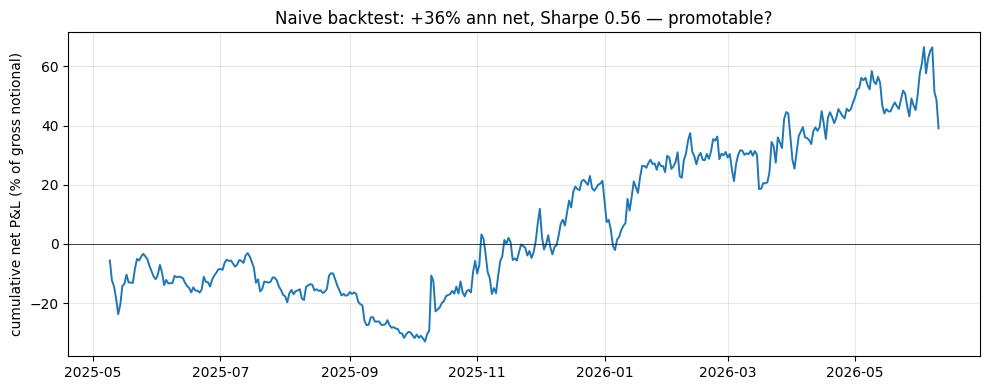

ann net    0.358
vol        0.640
sharpe     0.560
t-stat     0.585
maxDD     -0.299
dtype: float64

In [2]:
COST = 10e-4
BURN = 100   # days before first clean signal

def momentum_positions(lookback):
    factor = np.log(px.shift(7) / px.shift(lookback + 7))
    pos = pd.DataFrame(0.0, index=px.index, columns=px.columns)
    w_prev = pd.Series(0.0, index=px.columns)
    for d in px.index[::7]:
        f = factor.loc[d].dropna()
        if len(f) >= 30:
            q = len(f) // 5
            w = pd.Series(0.0, index=px.columns)
            w[f.nlargest(q).index] = 1.0 / q
            w[f.nsmallest(q).index] = -1.0 / q
            w_prev = w
        pos.loc[d:] = w_prev.values
    return pos

def evaluate(pos, vol_target=None):
    day = (pos.shift(1) * rets).sum(axis=1)
    if vol_target is not None:
        scale = (vol_target / np.sqrt(365)) / day.rolling(30).std().shift(1)
        pos = pos.mul(scale.clip(0, 3).fillna(0), axis=0)
        day = (pos.shift(1) * rets).sum(axis=1)
    turn = pos.diff().abs().sum(axis=1)
    net = (day - turn * COST).dropna()
    net = net[net.index > px.index[BURN]]
    ann, vol = net.mean() * 365, net.std() * np.sqrt(365)
    cum = net.cumsum()
    years = len(net) / 365
    return {"ann net": ann, "vol": vol, "sharpe": ann / vol,
            "t-stat": (ann / vol) * np.sqrt(years),
            "maxDD": (cum - cum.cummax()).min()}, net

stats90, net90 = evaluate(momentum_positions(90))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(net90.index, 100 * net90.cumsum(), lw=1.4)
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("cumulative net P&L (% of gross notional)")
ax.set_title(f"Naive backtest: +{stats90['ann net']:.0%} ann net, "
             f"Sharpe {stats90['sharpe']:.2f} — promotable?")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
pd.Series(stats90).map(lambda v: round(float(v), 3))

A +36% net equity curve is where most backtests stop and most pitches start.
The pipeline starts instead.

## 2. Gate check 1: is there any cross-sectional signal at all?

If a *ranking* factor works, forward returns should increase across its
quintiles. This is the most basic diagnostic there is, and the strategy P&L
already shown cannot be trusted until it passes.

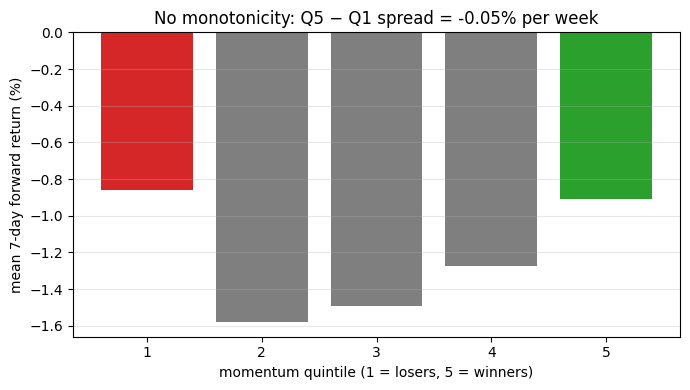

per-quintile weekly means (%): [-0.86 -1.58 -1.49 -1.27 -0.91]
naive backtest t-stat: 0.58  (needs ~2 to distinguish from zero)


In [3]:
factor = np.log(px.shift(7) / px.shift(97))
fwd7 = np.log(px.shift(-7) / px)
rows = []
for d in px.index[BURN:-7:7]:
    f = factor.loc[d].dropna()
    if len(f) < 30:
        continue
    q = pd.qcut(f.rank(method="first"), 5, labels=False)
    rows.append([fwd7.loc[d, f.index[q == i]].mean() for i in range(5)])
qmeans = np.nanmean(np.array(rows), axis=0) * 100

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, 6), qmeans, color=["tab:red"] + ["tab:gray"] * 3 + ["tab:green"])
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("momentum quintile (1 = losers, 5 = winners)")
ax.set_ylabel("mean 7-day forward return (%)")
ax.set_title(f"No monotonicity: Q5 − Q1 spread = {qmeans[4]-qmeans[0]:+.2f}% per week")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

print(f"per-quintile weekly means (%): {np.round(qmeans, 2)}")
print(f"naive backtest t-stat: {stats90['t-stat']:.2f}  "
      f"(needs ~2 to distinguish from zero)")

Two independent kills in one cell:

- **The quintile profile is flat** (slightly smile-shaped). Winners do not
  outperform losers over the following week on this universe and period. A
  long-short of Q5 against Q1 captures roughly nothing — so whatever the
  equity curve in §1 is, it is *not* the factor's selection ability.
- **t ≈ 0.6.** Even taking the backtest at face value, 1.1 years of a
  Sharpe-0.56 strategy is statistically indistinguishable from luck. (This
  is exactly why the production gate is expressed in Sharpe *and* minimum
  track length.)

## 3. Gate check 2: where did the +36% come from, then?

The unscaled long-short doubles its risk when crypto vol doubles — position
sizes are constant, the underlying isn't. If returns cluster in high-vol
regimes by chance, the raw cumulative P&L rewards that timing luck. The
test: run the *same* positions at constant risk (30-day trailing
vol-targeted to 20% annualized) and see if the P&L survives.

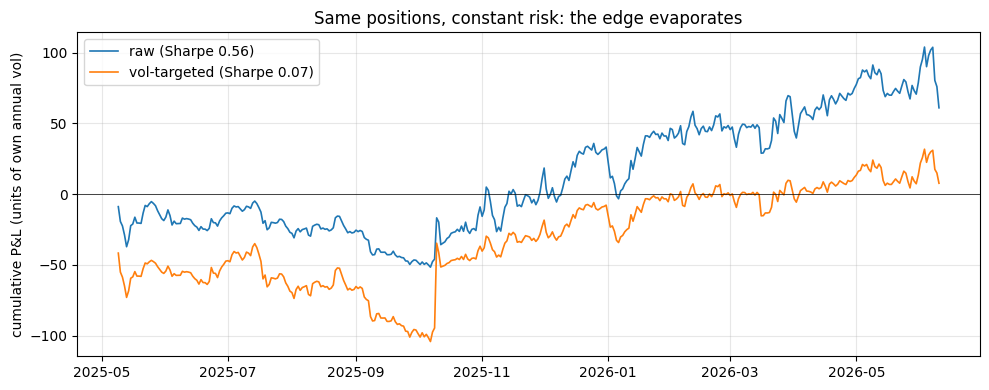

,raw,vol-targeted 20%
ann net,0.358,0.021
vol,0.640,0.292
sharpe,0.560,0.071
t-stat,0.585,0.074
maxDD,-0.299,-0.202


In [4]:
stats_vt, net_vt = evaluate(momentum_positions(90), vol_target=0.20)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(net90.index, 100 * net90.cumsum() / net90.std() / np.sqrt(365),
        lw=1.2, label=f"raw (Sharpe {stats90['sharpe']:.2f})")
ax.plot(net_vt.index, 100 * net_vt.cumsum() / net_vt.std() / np.sqrt(365),
        lw=1.2, label=f"vol-targeted (Sharpe {stats_vt['sharpe']:.2f})")
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("cumulative P&L (units of own annual vol)")
ax.set_title("Same positions, constant risk: the edge evaporates")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

pd.DataFrame({"raw": stats90, "vol-targeted 20%": stats_vt}).round(3)

At constant risk the strategy earns approximately nothing. The naive equity
curve was an *implementation artifact* — implicit vol-timing — stacked on a
selection signal that §2 already showed to be absent. Note the order of
operations matters: had we only run the vol-targeted version we would know
it fails, but not *why*; the quintile diagnostic localizes the failure to
the factor itself.

## 4. Gate check 3 (stage 2 proper): walk-forward selection

The production walk-forward stage answers: *if I had honestly tuned this in
the past, what would I have earned afterwards?* Tune the lookback over the
first 60% of history, deploy the winner untouched on the final 40%.

In [5]:
split = px.index[int(len(px) * 0.6)]
table = {}
for lb in (30, 60, 90, 180):
    _, net = evaluate(momentum_positions(lb))
    tr, te = net[net.index <= split], net[net.index > split]
    sh = lambda s: s.mean() * 365 / (s.std() * np.sqrt(365))
    table[f"lb={lb}d"] = {"IS sharpe": sh(tr), "OOS sharpe": sh(te),
                          "OOS ann net": te.mean() * 365}
table = pd.DataFrame(table).T
chosen = table["IS sharpe"].idxmax()
print(f"in-sample winner: {chosen} (IS Sharpe {table.loc[chosen, 'IS sharpe']:.2f}) "
      f"→ OOS Sharpe {table.loc[chosen, 'OOS sharpe']:.2f}, "
      f"OOS ann {table.loc[chosen, 'OOS ann net']:+.1%}")
table.round(2)

in-sample winner: lb=60d (IS Sharpe 1.32) → OOS Sharpe -0.10, OOS ann -7.6%


,IS sharpe,OOS sharpe,OOS ann net
lb=30d,1.28,0.09,0.06
lb=60d,1.32,-0.10,-0.08
lb=90d,-0.02,1.00,0.73
lb=180d,0.71,0.30,0.22


The in-sample winner (Sharpe 1.3 — comfortably above a naive promotion bar)
delivers **negative** out-of-sample performance. Four lookbacks is a tiny
search space; even so, picking the in-sample best inflated apparent Sharpe by
more than a full point. Production search spaces are orders of magnitude
larger, which is why the walk-forward gate is structural, not optional.

## 5. Verdict and what it takes to pass

**Rejected at stage 2 of 4.** The candidate never reaches paper trading,
let alone capital. Recorded reasons: no quintile monotonicity, t < 1,
P&L attributable to vol-timing artifact, negative walk-forward retention.

What a surviving cross-sectional crypto strategy has needed, in my
experience running the live book this pipeline feeds: more than one factor
family (price momentum alone is the most arbitraged signal in the asset
class), funding-aware construction (carry is a large, *observable* component
of cross-sectional returns in perps), regime conditioning, point-in-time
universes, and constant-risk implementation from day one so the backtest
measures selection — not sizing accidents.

The general principle this notebook demonstrates is the one I would defend
hardest: **a research process is measured by the quality of its rejections.**
Any pipeline can promote a good-looking equity curve; the job is to make
sure the curve is the strategy, not the costume.